In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# File paths
bot_path = "/content/bot-iot.csv"
ton_path = "/content/ton-iot.csv"

# Load
bot_df = pd.read_csv(bot_path)
ton_df = pd.read_csv(ton_path)

print("BOT-IoT Shape:", bot_df.shape)
print("TON-IoT Shape:", ton_df.shape)

BOT-IoT Shape: (143350, 46)
TON-IoT Shape: (19, 45)


In [ ]:
def clean_data(df):
    df = df.drop_duplicates()
    df = df.dropna()
    return df

bot_df = clean_data(bot_df)
ton_df = clean_data(ton_df)

In [ ]:
ton_df.replace('-', 'nil', inplace=True)

In [ ]:
def encode_dataframe(df):
    df_encoded = df.copy()

    for col in df_encoded.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    return df_encoded

bot_df = encode_dataframe(bot_df)
ton_df = encode_dataframe(ton_df)

In [ ]:
bot_targets = ['attack', 'category', 'subcategory']

X_bot = bot_df.drop(columns=bot_targets)
y_bot = bot_df[bot_targets]

In [ ]:
ton_target = 'label'

X_ton = ton_df.drop(columns=[ton_target])
y_ton = ton_df[ton_target]

In [ ]:
scaler_bot = MinMaxScaler()
scaler_ton = MinMaxScaler()

X_bot = scaler_bot.fit_transform(X_bot)
X_ton = scaler_ton.fit_transform(X_ton)

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bot, y_bot, test_size=0.2, random_state=42
)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_ton, y_ton, test_size=0.2, random_state=42, stratify=y_ton
)

In [ ]:
bot_model = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42)
)

bot_model.fit(Xb_train, yb_train)

bot_pred = bot_model.predict(Xb_test)

In [ ]:
print("BOT-IoT Evaluation Results")

for i, col in enumerate(yb_test.columns):
    print(f"\nTarget: {col}")
    print("Accuracy:", accuracy_score(yb_test.iloc[:, i], bot_pred[:, i]))
    print(classification_report(yb_test.iloc[:, i], bot_pred[:, i]))

BOT-IoT Evaluation Results

Target: attack
Accuracy: 1.0
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     28670

    accuracy                           1.00     28670
   macro avg       1.00      1.00      1.00     28670
weighted avg       1.00      1.00      1.00     28670


Target: category
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28670

    accuracy                           1.00     28670
   macro avg       1.00      1.00      1.00     28670
weighted avg       1.00      1.00      1.00     28670


Target: subcategory
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00     28364

    accuracy                           1.00     28670
   macro avg       1.00      1.00      1.00     28670
weighted avg       1.00      1.00      1.00     28670



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


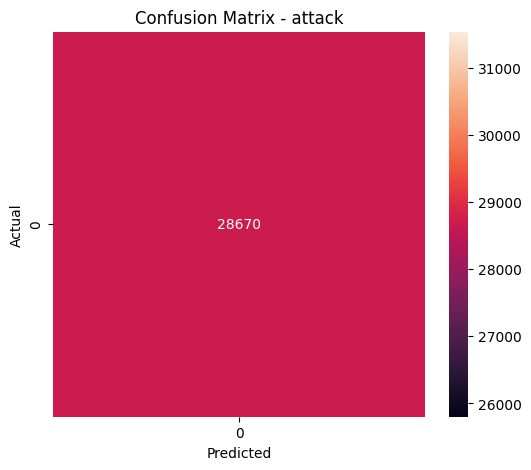

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


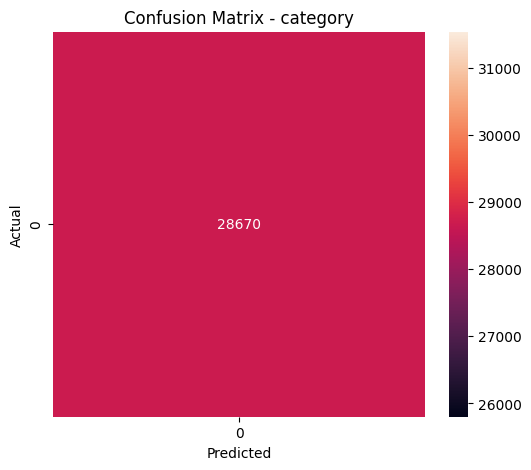

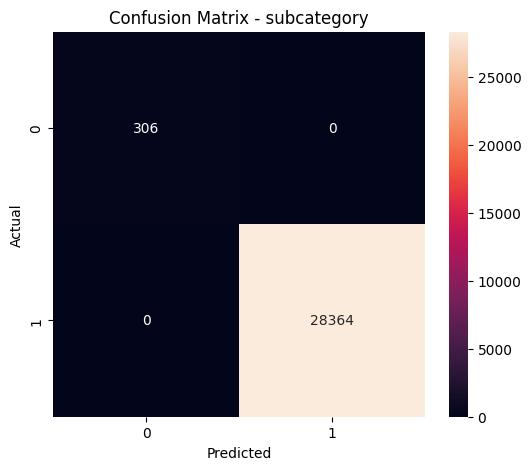

In [ ]:
for i, col in enumerate(yb_test.columns):
    cm = confusion_matrix(yb_test.iloc[:, i], bot_pred[:, i])

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {col}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
ton_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

ton_model.fit(Xt_train, yt_train)

ton_pred = ton_model.predict(Xt_test)

In [ ]:
print("\nTON-IoT Evaluation Results")

print("Accuracy:", accuracy_score(yt_test, ton_pred))
print(classification_report(yt_test, ton_pred))


TON-IoT Evaluation Results
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



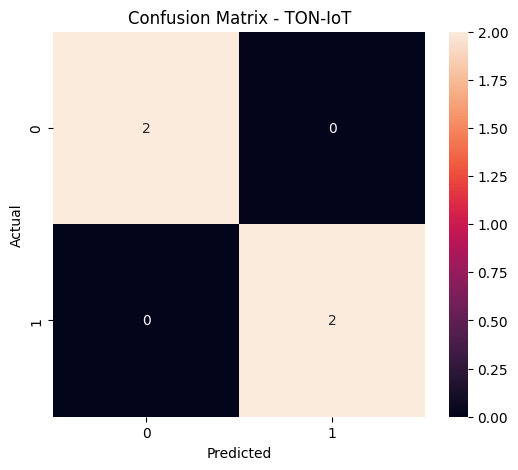

In [ ]:
cm = confusion_matrix(yt_test, ton_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - TON-IoT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

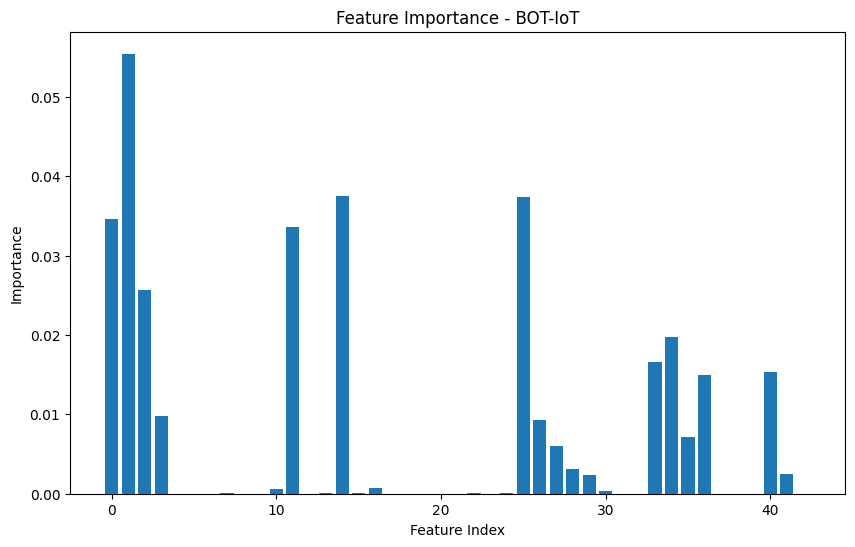

In [ ]:
importances = np.mean(
    [est.feature_importances_ for est in bot_model.estimators_],
    axis=0
)

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - BOT-IoT")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [ ]:
pickle.dump(bot_model, open("bot_model.pkl", "wb"))
pickle.dump(ton_model, open("ton_model.pkl", "wb"))

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

In [ ]:
MultiOutputClassifier(RandomForestClassifier())

MultiOutputClassifier(estimator=RandomForestClassifier())

In [ ]:
bot_models = {
    "Logistic Regression": MultiOutputClassifier(
        LogisticRegression(max_iter=1000)
    ),

    "SVM": MultiOutputClassifier(
        SVC(kernel='rbf')
    ),

    "KNN": MultiOutputClassifier(
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Random Forest": MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, random_state=42)
    ),

    "MLP": MultiOutputClassifier(
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    )
}

In [ ]:
bot_results = []

# Identify columns with single unique classes
single_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() < 2]
multi_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() >= 2]

# Prepare filtered y_train and y_test for multi-class columns
yb_train_filtered = yb_train[multi_class_cols]
yb_test_filtered = yb_test[multi_class_cols]

for name, model in bot_models.items():
    print(f"\nTraining {name}...")

    acc_list = []

    if multi_class_cols:  # Only train if there are multi-class columns
        # Fit the model on multi-class targets
        model.fit(Xb_train, yb_train_filtered)
        predictions_multi_class = model.predict(Xb_test)

        # Store predictions for multi-class columns and calculate accuracy
        for i, col in enumerate(multi_class_cols):
            acc = accuracy_score(yb_test_filtered.iloc[:, i], predictions_multi_class[:, i])
            acc_list.append(acc)

    # For single-class columns, accuracy is always 1.0
    for col in single_class_cols:
        acc_list.append(1.0)

    avg_accuracy = np.mean(acc_list)

    bot_results.append({
        "Model": name,
        "Average Accuracy": avg_accuracy
    })

bot_results_df = pd.DataFrame(bot_results)
bot_results_df.sort_values(by="Average Accuracy", ascending=False)


Training Logistic Regression...

Training SVM...

Training KNN...

Training Random Forest...

Training MLP...


,Model,Average Accuracy
2,KNN,1.000000
3,Random Forest,1.000000
0,Logistic Regression,0.999988
4,MLP,0.999988
1,SVM,0.999977


In [ ]:
ton_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(kernel='rbf'),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),

    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

In [ ]:
ton_results = []

for name, model in ton_models.items():
    print(f"\nTraining {name}...")

    model.fit(Xt_train, yt_train)
    predictions = model.predict(Xt_test)

    acc = accuracy_score(yt_test, predictions)

    ton_results.append({
        "Model": name,
        "Accuracy": acc
    })

ton_results_df = pd.DataFrame(ton_results)
ton_results_df.sort_values(by="Accuracy", ascending=False)


Training Logistic Regression...

Training SVM...

Training KNN...

Training Random Forest...

Training MLP...


,Model,Accuracy
0,Logistic Regression,1.0
1,SVM,1.0
2,KNN,1.0
3,Random Forest,1.0
4,MLP,1.0


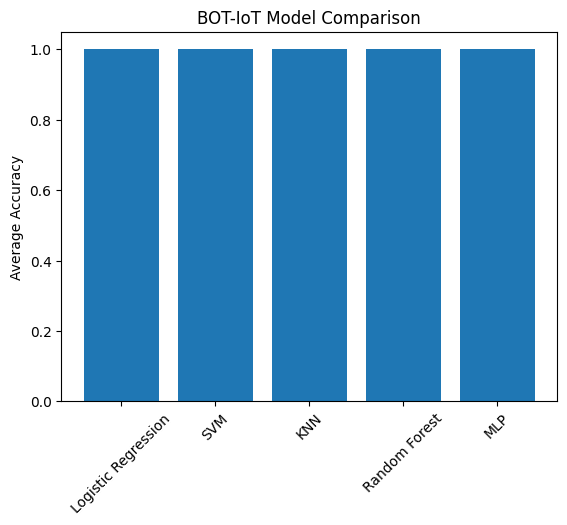

In [ ]:
plt.figure()
plt.bar(bot_results_df["Model"], bot_results_df["Average Accuracy"])
plt.xticks(rotation=45)
plt.title("BOT-IoT Model Comparison")
plt.ylabel("Average Accuracy")
plt.show()

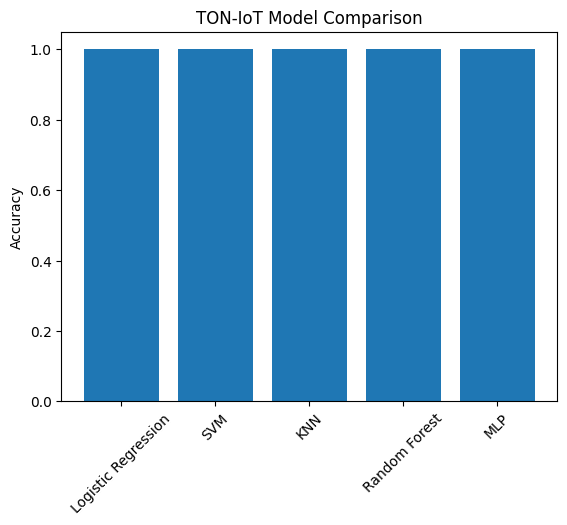

In [ ]:
plt.figure()
plt.bar(ton_results_df["Model"], ton_results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("TON-IoT Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
ton_results = []

for name, model in ton_models.items():
    print(f"\nTraining {name}...")

    model.fit(Xt_train, yt_train)
    predictions = model.predict(Xt_test)

    ton_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yt_test, predictions),
        "Precision (Weighted)": precision_score(yt_test, predictions, average='weighted'),
        "Recall (Weighted)": recall_score(yt_test, predictions, average='weighted'),
        "F1-Score (Weighted)": f1_score(yt_test, predictions, average='weighted')
    })

ton_results_df = pd.DataFrame(ton_results)
ton_results_df.sort_values(by="F1-Score (Weighted)", ascending=False)



Training Logistic Regression...

Training SVM...

Training KNN...

Training Random Forest...

Training MLP...


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Logistic Regression,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,KNN,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0
4,MLP,1.0,1.0,1.0,1.0


In [ ]:
bot_results = []

# Identify columns with single unique classes
single_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() < 2]
multi_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() >= 2]

# Prepare filtered y_train and y_test for multi-class columns
yb_train_filtered = yb_train[multi_class_cols]
yb_test_filtered = yb_test[multi_class_cols]

for name, model in bot_models.items():
    print(f"\nTraining {name}...")

    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    if multi_class_cols:  # Only train if there are multi-class columns
        # Fit the model on multi-class targets
        model.fit(Xb_train, yb_train_filtered)
        predictions = model.predict(Xb_test)

        # Store predictions for multi-class columns and calculate accuracy
        for i, col in enumerate(multi_class_cols):
            acc_list.append(accuracy_score(yb_test_filtered.iloc[:, i], predictions[:, i]))
            prec_list.append(precision_score(yb_test_filtered.iloc[:, i], predictions[:, i], average='weighted', zero_division=0))
            rec_list.append(recall_score(yb_test_filtered.iloc[:, i], predictions[:, i], average='weighted', zero_division=0))
            f1_list.append(f1_score(yb_test_filtered.iloc[:, i], predictions[:, i], average='weighted', zero_division=0))

    # For single-class columns, accuracy, precision, recall, and f1 are always 1.0
    for col in single_class_cols:
        acc_list.append(1.0)
        prec_list.append(1.0)
        rec_list.append(1.0)
        f1_list.append(1.0)

    bot_results.append({
        "Model": name,
        "Accuracy": np.mean(acc_list),
        "Precision (Weighted)": np.mean(prec_list),
        "Recall (Weighted)": np.mean(rec_list),
        "F1-Score (Weighted)": np.mean(f1_list)
    })

bot_results_df = pd.DataFrame(bot_results)
bot_results_df.sort_values(by="F1-Score (Weighted)", ascending=False)


Training Logistic Regression...

Training SVM...

Training KNN...

Training Random Forest...

Training MLP...


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
2,KNN,1.000000,1.000000,1.000000,1.000000
3,Random Forest,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.999988,0.999988,0.999988,0.999988
4,MLP,0.999988,0.999988,0.999988,0.999988
1,SVM,0.999977,0.999977,0.999977,0.999977


In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
ton_stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(kernel='rbf', probability=True)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

In [ ]:
ton_stacking.fit(Xt_train, yt_train)
ton_stack_pred = ton_stacking.predict(Xt_test)

print("STACKING MODEL RESULTS (TON-IoT)")
print("Accuracy:", accuracy_score(yt_test, ton_stack_pred))
print("Precision:", precision_score(yt_test, ton_stack_pred, average='weighted'))
print("Recall:", recall_score(yt_test, ton_stack_pred, average='weighted'))
print("F1:", f1_score(yt_test, ton_stack_pred, average='weighted'))

STACKING MODEL RESULTS (TON-IoT)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [ ]:
bot_stacking = MultiOutputClassifier(
    StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('svm', SVC(kernel='rbf', probability=True)),
            ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=5
    )
)

In [ ]:
acc_list, prec_list, rec_list, f1_list = [], [], [], []

# Identify columns with single unique classes
single_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() < 2]
multi_class_cols = [col for col in yb_train.columns if yb_train[col].nunique() >= 2]

# Prepare filtered y_train and y_test for multi-class columns
yb_train_filtered = yb_train[multi_class_cols]
yb_test_filtered = yb_test[multi_class_cols]

if multi_class_cols:  # Only train if there are multi-class columns
    bot_stacking.fit(Xb_train, yb_train_filtered)
    bot_stack_pred = bot_stacking.predict(Xb_test)

    # Store predictions for multi-class columns and calculate accuracy
    for i, col in enumerate(multi_class_cols):
        acc_list.append(accuracy_score(yb_test_filtered.iloc[:, i], bot_stack_pred[:, i]))
        prec_list.append(precision_score(yb_test_filtered.iloc[:, i], bot_stack_pred[:, i], average='weighted', zero_division=0))
        rec_list.append(recall_score(yb_test_filtered.iloc[:, i], bot_stack_pred[:, i], average='weighted', zero_division=0))
        f1_list.append(f1_score(yb_test_filtered.iloc[:, i], bot_stack_pred[:, i], average='weighted', zero_division=0))

# For single-class columns, accuracy, precision, recall, and f1 are always 1.0
for col in single_class_cols:
    acc_list.append(1.0)
    prec_list.append(1.0)
    rec_list.append(1.0)
    f1_list.append(1.0)

print("STACKING MODEL RESULTS (BOT-IoT)")
print("Accuracy:", np.mean(acc_list))
print("Precision:", np.mean(prec_list))
print("Recall:", np.mean(rec_list))
print("F1:", np.mean(f1_list))

STACKING MODEL RESULTS (BOT-IoT)
Accuracy: 0.9999883734449483
Precision: 0.9999884113164631
Recall: 0.9999883734449483
F1: 0.9999883828257939
